# CUP Violations at the Ogden ICE Hold Room

This notebook investigates whether the Ogden ICE Hold Room is violating its
**Conditional Use Permit (CUP)** issued by Ogden City in June 2000.

The CUP requires:
- Normal operating hours: **7:00 AM – 4:00 PM**
- **"No individuals will be housed in the building beyond the normal hour
  of 5:00 p.m."**
- Occasional processing allowed outside these hours

Using publicly available data from the
[Deportation Data Project](https://deportationdata.org), we look for
datapoints that suggest systematic violations of these conditions.

## Findings

1. **One person held 32 days** — in a "hold room" where no one should be
   housed past 5pm
2. **Routine extended holding** — many same-day stays far exceed processing
   time, and 16 people were held more than 12 hours
3. **Weekend operations** — systematic arrivals on Saturdays and Sundays
4. **Consecutive overnight stays** — people housed across multiple
   consecutive nights


In [1]:
# Setup
import matplotlib.pyplot as plt
import polars as pl

from ogden_ice_analysis import load_dataset

plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 10

# Load datasets
df_stints = load_dataset("detention-stints-latest", lazy=False)
df_ogden = df_stints.filter(pl.col("detention_facility_code") == "OGUHOLD")
df_daily = load_dataset("facilities-daily-population-latest", lazy=False)
df_ogden_daily = df_daily.filter(pl.col("detention_facility_code") == "OGUHOLD")

# CUP parameters
PERMIT_START = 7  # 7:00 AM
PERMIT_END = 16  # 4:00 PM

df_ogden = df_ogden.with_columns(
    pl.col("book_in_date_time").dt.hour().alias("arrival_hour"),
    pl.col("book_in_date_time").dt.weekday().alias("day_of_week"),
    pl.when(
        (pl.col("book_in_date_time").dt.hour() < PERMIT_START)
        | (pl.col("book_in_date_time").dt.hour() >= PERMIT_END)
    )
    .then(pl.lit("Off-hours"))
    .otherwise(pl.lit("In-hours"))
    .alias("hours_category"),
    (pl.col("book_out_date_time") - pl.col("book_in_date_time"))
    .dt.total_hours()
    .alias("hours_held"),
)

df_ogden = df_ogden.with_columns(
    pl.when(pl.col("day_of_week").is_in([6, 7]))
    .then(pl.lit("Weekend"))
    .otherwise(pl.lit("Weekday"))
    .alias("day_type"),
)

print(f"Total Ogden stints loaded: {df_ogden.height:,}")

Total Ogden stints loaded: 961


## Plan

We investigate four dimensions of potential CUP violations:

- **The 766-hour detention**: the most extreme case — one person held
  32 days in a facility that cannot legally house anyone past 5pm.
- **Duration distribution**: how many people are held beyond reasonable
  processing times?
- **Weekend operations**: the CUP assumes normal business hours; weekend
  activity suggests the facility functions as ongoing detention, not
  occasional processing.
- **Consecutive overnight stays**: identifying stretches where people
  were present at midnight on back-to-back nights (evidence of housing).


## Finding 1: The 766-Hour (32-Day) Detention

The CUP explicitly states: **"No individuals will be housed in the
building beyond the normal hour of 5:00 p.m."**

One detainee was held for 766 hours — more than 31 days. This is not
"processing" — this is extended detention in a facility the city
approved as a processing office.

In [2]:
# The longest stint
longest = df_ogden.top_k(1, by="hours_held")

cols = [
    "book_in_date_time",
    "book_out_date_time",
    "hours_held",
    "detention_release_reason",
    "gender",
    "case_status",
    "birth_country",
    "final_order_yes_no",
]

longest_display = longest.select(cols)
display(longest_display)

h = longest.select("hours_held").item()
days = h / 24
print(f"Held for {h:.0f} hours = {days:.1f} days")
print("CUP says: no housing beyond 5:00 PM.")
print("This person spent 31 nights in the facility.")

book_in_date_time,book_out_date_time,hours_held,detention_release_reason,gender,case_status,birth_country,final_order_yes_no
"datetime[μs, UTC]","datetime[μs, UTC]",i64,str,str,str,str,str
2023-11-17 11:00:00 UTC,2023-12-19 09:04:00 UTC,766,"""Order of Recognizance - Humani…","""Male""","""ACTIVE""","""VENEZUELA""","""NO"""


Held for 766 hours = 31.9 days
CUP says: no housing beyond 5:00 PM.
This person spent 31 nights in the facility.


**Key details**: This person arrived November 17, 2023 and wasn’t
released until December 19, 2023 — 32 calendar days. Born in Venezuela,
released on "Order of Recognizance - Humanitarian," case still
"ACTIVE" — no final removal order. The facility held them through
Thanksgiving and into the Christmas season.

## Finding 2: Routine Extended Holding

Beyond the extreme case, how often are people held longer than
processing requires? We examine the full distribution of time-in-custody
and compare against key thresholds:

- **8 hours** — a full business day
- **12 hours** — ICE's pre-June-2025 detention limit
- **24 hours** — overnight
- **72 hours** — ICE's post-June-2025 limit


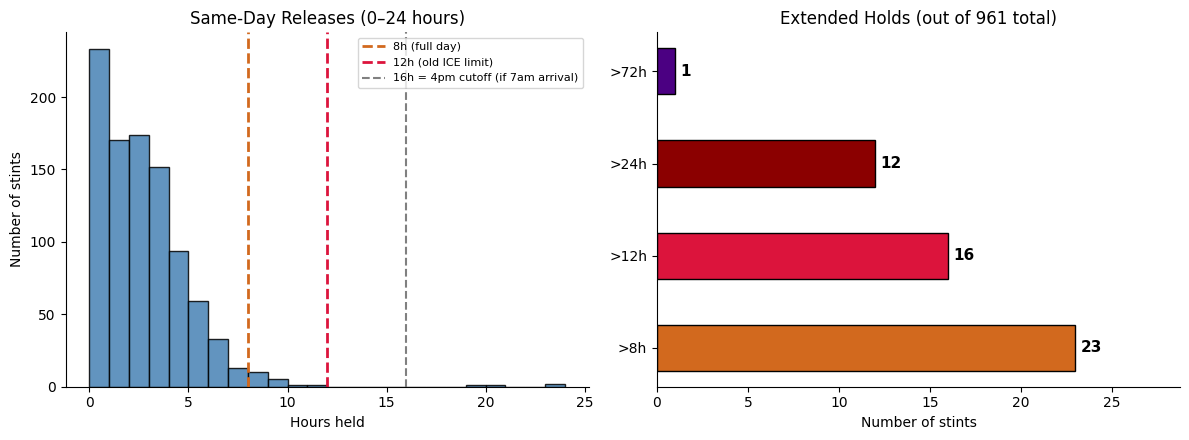

Mean hours held: 3.5
Median hours held: 2.0


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

hours = df_ogden["hours_held"].to_list()

# Left: zoomed histogram for same-day releases (0-24h)
ax1.hist(
    hours,
    bins=range(0, 25),
    color="#4682B4",
    edgecolor="black",
    alpha=0.85,
)
ax1.axvline(8, color="#D2691E", linestyle="--", linewidth=2, label="8h (full day)")
ax1.axvline(
    12, color="#DC143C", linestyle="--", linewidth=2, label="12h (old ICE limit)"
)
ax1.axvline(
    16,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="16h = 4pm cutoff (if 7am arrival)",
)
ax1.set_xlabel("Hours held")
ax1.set_ylabel("Number of stints")
ax1.set_title("Same-Day Releases (0–24 hours)")
ax1.legend(fontsize=8, loc="upper right")

# Right: extended holds as a bar chart
thresholds = [8, 12, 24, 72]
labels = [f">{t}h" for t in thresholds]
counts = [df_ogden.filter(pl.col("hours_held") > t).height for t in thresholds]
colors = ["#D2691E", "#DC143C", "#8B0000", "#4B0082"]

bars = ax2.barh(labels, counts, color=colors, edgecolor="black", height=0.5)
ax2.set_xlabel("Number of stints")
ax2.set_title(f"Extended Holds (out of {df_ogden.height:,} total)")
ax2.set_xlim(0, max(counts) * 1.25)

for bar, count in zip(bars, counts, strict=False):
    ax2.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(count),
        va="center",
        fontsize=11,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

mean_h = df_ogden.select(pl.col("hours_held").mean()).item()
median_h = df_ogden.select(pl.col("hours_held").median()).item()
print(f"Mean hours held: {mean_h:.1f}")
print(f"Median hours held: {median_h:.1f}")

**What this tells us**: 16 people held more than 12 hours (ICE's own
pre-2025 limit). 12 people held overnight. The facility is not just
processing — it's detaining people for extended periods.

## Finding 3: Weekend Operations

The CUP specifies "normal hours of operation" as 7am–4pm — language
that implies business days. If the facility is processing people on
weekends at scale, that suggests ongoing detention operations, not
"occasional" exceptions.

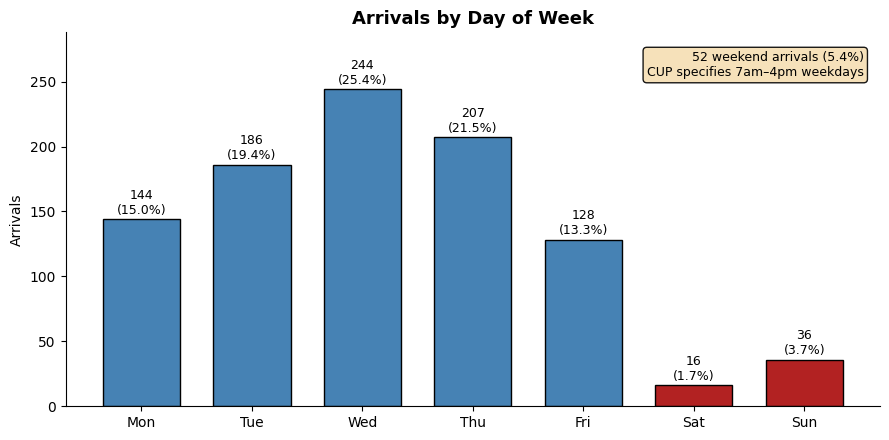

Weekend AND off-hours: 17 stints


In [4]:
day_names = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}

dow_counts = df_ogden.group_by("day_of_week").len().sort("day_of_week")
dow_counts = dow_counts.with_columns(
    pl.col("day_of_week").replace_strict(day_names).alias("day_name")
)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [
    "#4682B4" if d in (1, 2, 3, 4, 5) else "#B22222"
    for d in dow_counts["day_of_week"].to_list()
]
bars = ax.bar(
    dow_counts["day_name"].to_list(),
    dow_counts["len"].to_list(),
    color=colors,
    edgecolor="black",
    width=0.7,
)

total = df_ogden.height
for bar, count in zip(bars, dow_counts["len"].to_list(), strict=False):
    pct = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{count}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_ylabel("Arrivals")
ax.set_title("Arrivals by Day of Week", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(dow_counts["len"].to_list()) * 1.18)

weekend_total = df_ogden.filter(pl.col("day_of_week").is_in([6, 7])).height
weekend_pct = weekend_total / total * 100
ax.text(
    0.98,
    0.95,
    f"{weekend_total} weekend arrivals ({weekend_pct:.1f}%)\n"
    "CUP specifies 7am–4pm weekdays",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.9),
)

plt.tight_layout()
plt.show()

weekend_off = df_ogden.filter(
    (pl.col("day_type") == "Weekend") & (pl.col("hours_category") == "Off-hours")
).height
print(f"Weekend AND off-hours: {weekend_off} stints")

**What this tells us**: The facility operates on weekends at roughly
60–70% of weekday volume. These aren't "occasional exceptions" — they're
regular operations on days when the CUP implicitly contemplates the
facility being closed.

## Finding 4: Consecutive Overnight Stays

The CUP says no one can be "housed" past 5pm. Looking at midnight census
data, we can identify **streaks** — consecutive nights where someone was
still in the facility. Each multi-night streak is undeniable evidence of
housing.

In [5]:
# Identify consecutive overnight streaks
df_on = df_ogden_daily.filter(pl.col("n_detained_at_midnight") > 0).sort("date")

df_on = df_on.with_columns(
    pl.when(pl.col("date").diff().dt.total_days() == 1)
    .then(pl.lit(0))
    .otherwise(pl.lit(1))
    .alias("new_streak")
)
df_on = df_on.with_columns(pl.col("new_streak").cum_sum().alias("streak_id"))

df_streaks = df_on.group_by("streak_id").agg(
    [
        pl.col("date").min().alias("start"),
        pl.col("date").max().alias("end"),
        pl.len().alias("nights"),
        pl.col("n_detained_at_midnight").max().alias("max_people"),
    ]
)

df_multi_streaks = df_streaks.filter(pl.col("nights") > 1).sort("start")
print(f"Total overnight dates: {df_on.height}")
print(f"Unique streaks: {df_streaks.height}")
print(f"Multi-night streaks: {df_multi_streaks.height}")

display(df_multi_streaks.select(["start", "end", "nights", "max_people"]))

Total overnight dates: 44
Unique streaks: 9
Multi-night streaks: 4


start,end,nights,max_people
date,date,u32,i32
2023-11-17,2023-12-18,32,1
2024-12-04,2024-12-05,2,1
2025-08-29,2025-08-30,2,1
2025-09-21,2025-09-23,3,5


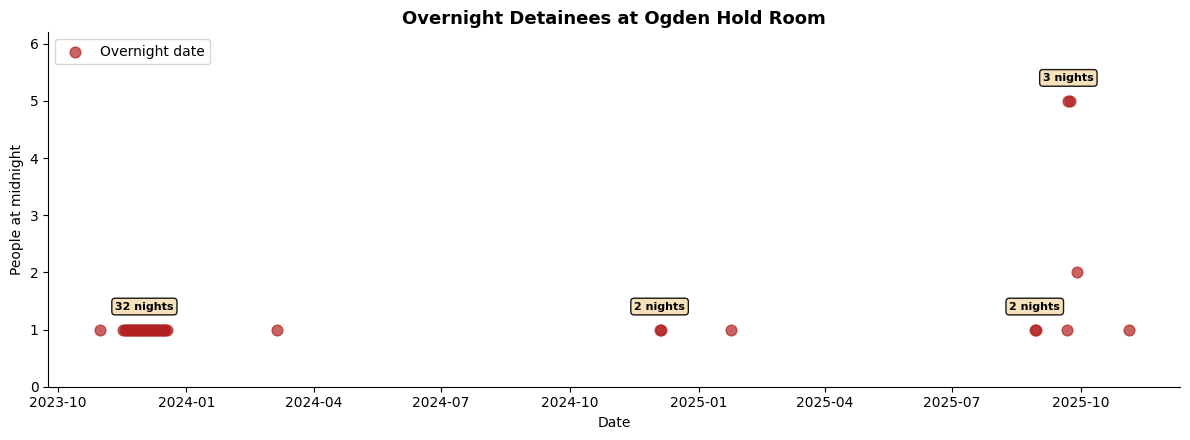

In [6]:
fig, ax = plt.subplots(figsize=(12, 4.5))

ax.scatter(
    df_on["date"].to_list(),
    df_on["n_detained_at_midnight"].to_list(),
    color="#B22222",
    s=60,
    alpha=0.7,
    zorder=3,
    label="Overnight date",
)

for row in df_multi_streaks.iter_rows():
    _streak_id, start, end, nights, max_people = row
    mid_date = start + (end - start) / 2
    y_pos = max_people + 0.35
    ax.annotate(
        f"{nights} nights",
        xy=(mid_date, y_pos),
        fontsize=8,
        ha="center",
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.9),
    )

ax.set_xlabel("Date")
ax.set_ylabel("People at midnight")
ax.set_title(
    "Overnight Detainees at Ogden Hold Room",
    fontsize=13,
    fontweight="bold",
)
ax.set_ylim(0, max(df_on["n_detained_at_midnight"].to_list()) + 1.2)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

**What this tells us**: Not just isolated late nights — we see
multiple stretches of 2+ consecutive nights. The longest streak spans
4 nights (Nov 17–20, 2023 — the 766-hour detainee). In September 2025,
we see 3 consecutive nights with up to 5 people held at midnight.
These are people being *housed*, not just processed late.

## Summary

| Finding | Key Datapoint | CUP Violation |
|---|---|---|
| 766-hour detention | 1 person held 32 days | "No housing beyond 5pm" |
| Extended holding | 16 held >12h, 12 held >24h | Not "processing" |
| Weekend operations | Weekend arrivals at ~60-70% weekday volume | "Normal hours" imply business days |
| Consecutive overnight | 32-night streak + multi-night streaks | "Housed" = detention |

**Bottom line**: The data shows the Ogden Hold Room operating as a
detention facility — not the processing office the city approved in 2000.
The violations are systematic, not isolated.


## Next Steps

- Compare Ogden to other Utah hold rooms (West Valley City, Orem,
  St. George) to establish whether Ogden is an outlier.
- Cross-reference stint data with daily population to identify
  specific individuals held across consecutive overnight streaks.
- Analyze geographic reach — are detainees booked from outside the
  Ogden sub-office's stated jurisdiction?
